# Transfer learning (ResNet18)

Extracting the dataset

In [9]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -q "/content/drive/MyDrive/Traffic Sign Recognition/dataset.zip" -d /content/data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Verifying it extracted correclty

In [10]:
import os
print(os.listdir('/content/data'))

['Test.csv', 'test', 'Train', 'train', 'Train.csv', 'Test', 'Meta', 'meta', 'Meta.csv']


## Imports + device

In [6]:
import os
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## Image transforms
Two separate transform pipelines one for the training images, and one for the validation images, mostly the same, but with training images, we augment them, with ColorJitter and RandomRotation to reduce overfitting. At the end we normalize the image to ResNet18 expected input normalization, this is important because pretrained models expect input data scaled to match the distribution they were trained on, and for faster convergence.

In [15]:
IMG_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(), # Normalizing each pixel value between 0-1
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

## Load CSV + train/validate split

Here we load the CSV data and create 85/15 train/validate split. We use stratification to pick the images, so that not one class is "over picked".

In [11]:
fdata_root = '/content/data'

full_dataframe = pd.read_csv(f'{data_root}/Train.csv')

train_dataframe, val_dataframe = train_test_split(
    full_dataframe,
    test_size=0.15,
    stratify=full_dataframe['ClassId'],
    random_state=42
)

print(len(train_dataframe), len(val_dataframe))

33327 5882


## The Dataset class
Pytorch DataLoader needs a class with __len__ and __getitem__ to know how many samples exist and how to fetch one by index, this is what our class provides. It takes a dataframe, the image root folder, and a transform as parameters, so the same class can be used for training, validation and test sets, just by passing in different dataframes/transforms.

In [13]:
class GTSRBDataset(Dataset):
    def __init__(self, dataframe, root, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root = root
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(os.path.join(self.root, row['Path'])).convert('RGB')
        image = self.transform(image)
        label = int(row['ClassId'])
        return image, label

## Creating the Dataset objects and DataLoaders

Here we instanitate the class we made before, one for the train set and one for the validation set each with its own dataframe and transform. Each Dataset is then wrapped in a DataLoader which handles batching, and parallel image loading.
Training data is shuffled each epoch so the model doesnt pick up on any accidental ordering in the data.

In [17]:
BATCH_SIZE = 64

train_dataset = GTSRBDataset(train_dataframe, data_root, train_transform)
val_dataset = GTSRBDataset(val_dataframe, data_root, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(len(train_dataset), len(val_dataset))

33327 5882


## Loading pretrained ResNet18 + swapping the final layer
Here we load the pretrained resnet18, and we swap the final fully connected layer with our own, linear layer, input size is the same as the original last layer input size, we just change the output to our number of classes.

ResNet18 comes pretrained on 1.2M images with 1000 classes, so its convolutional layers already know how to detect general visual features (edges, shapes, textures), these are feature that transfer well to new image tasks.

In [21]:
import torch.nn as nn
from torchvision import models

NUM_CLASSES = 43

model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES) # Replacing the last layer with a brand new linear layer, same number inputs, 43 output instead of 1000
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s]


## Loss function + optimizer
CrossEntropyLoss measures how far the predicted class scores are from the correct label. Adam updates the model's weights each step to reduce that loss , using a small learning rate, since we're fine-tuning pretrained weights and want to nudge them just slightly, rather then overwrite what they have already learned.

In [22]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

## Training loop setup
Creates a weights/resnet18 folder to store checkpoints, sets the number of training epochs, and initialized best_val_accuracy to 0, so that we can track the best performing model as the training progresses.

In [23]:
import os

os.makedirs('weights/resnet18', exist_ok=True)

EPOCHS = 15
best_val_accuracy = 0.0

## Training step (one epoch)
Runs one full pass over the training data. model.train() puts the model into training mode. for each batch: gradients are cleared (optimizer.zero_grad()), a forward pass produces predictions (model(images)) the loss is computed againts the true labels, loss.backwards() computes gradients with backpropagation, and optimizer.step() updates the modal's weights using these gradients. Running loss and accuracy are averaged across all batches (at the end of an epoch).

In [24]:
def train_one_epoch():
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy

## Validation step
Runs one full pass over the validation data to check how well the model generalizes to data it wasnt trained on. model.eval() switches the model to evaluation mode (dropout/batchnorm behave differently than in training - dropout turns off, batchnorm uses running statistics instead of the current batch). torch.no_grad() disabled gradient tracking entirely, since we're only measuring performance here, not updating the weights, this also makes it faster and uses less memory. Otherwise it mirrows train_once_epoch(), just no zero_grad(), backward() or optimizer.step(), since nothing is being learned.

In [25]:
def validate_one_epoch():
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy

## Main training loop
Runs the full training loop for 15 epochs. Each epoch: train_one_epoch() trains on the training set, validate_one_epoch() checks performance on the validation step, and the results (loss/accuracy for both, plus how long each epoch took) are printed to track progress over time.

Two checkpoints are saved each epoch: last.pt is overwritten every single epoch, always holding the most recent model state. best.pt is only overwritten when validation accuracy improves on the previous best.


In [26]:
import time

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_accuracy = train_one_epoch()
    val_loss, val_accuracy = validate_one_epoch()

    epoch_time = time.time() - start_time

    print(f'Epoch {epoch+1}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_accuracy:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_accuracy:.4f} | '
          f'Time: {epoch_time:.1f}s')

    torch.save(model.state_dict(), 'weights/resnet18/last.pt')

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'weights/resnet18/best.pt')
        print(f'  -> New best model saved (val acc: {val_accuracy:.4f})')

Epoch 1/15 | Train Loss: 0.5182 Acc: 0.8603 | Val Loss: 0.0205 Acc: 0.9952 | Time: 47.3s
  -> New best model saved (val acc: 0.9952)
Epoch 2/15 | Train Loss: 0.0367 Acc: 0.9899 | Val Loss: 0.0103 Acc: 0.9971 | Time: 43.8s
  -> New best model saved (val acc: 0.9971)
Epoch 3/15 | Train Loss: 0.0193 Acc: 0.9942 | Val Loss: 0.0183 Acc: 0.9959 | Time: 44.1s
Epoch 4/15 | Train Loss: 0.0143 Acc: 0.9958 | Val Loss: 0.0081 Acc: 0.9978 | Time: 43.2s
  -> New best model saved (val acc: 0.9978)
Epoch 5/15 | Train Loss: 0.0150 Acc: 0.9956 | Val Loss: 0.0144 Acc: 0.9957 | Time: 43.2s
Epoch 6/15 | Train Loss: 0.0120 Acc: 0.9963 | Val Loss: 0.0036 Acc: 0.9990 | Time: 43.4s
  -> New best model saved (val acc: 0.9990)
Epoch 7/15 | Train Loss: 0.0102 Acc: 0.9972 | Val Loss: 0.0016 Acc: 0.9997 | Time: 43.5s
  -> New best model saved (val acc: 0.9997)
Epoch 8/15 | Train Loss: 0.0098 Acc: 0.9976 | Val Loss: 0.0051 Acc: 0.9978 | Time: 43.6s
Epoch 9/15 | Train Loss: 0.0131 Acc: 0.9962 | Val Loss: 0.0047 Acc: 

# **Custom CNN**

## Custom CNN Class skeleton + conv layers
A CNN without pretrained weights compare againts ResNet18 transfer-learning baseline. It has 3 convolutional blocks, each doubling the channel count (3 -> 32 -> 64 -> 128) while MaxPool2d halves the spatial size after each block (64 -> 32 -> 16 -> 8). Each block is Conv2d -> BatchNorm2d -> ReLU -> MaxPool: the conv layer extract features, batchnorm stabilizes/normalizes activations for more stable training, and ReLU adds non-linearity.

After the 3rd block, the output (128 channels of 8x8 feature maps) is flattened and passed through two fully connected layers (fc1: 8192 -> 256, fc2: 256 -> 43) to produce final class scores. Dropout(0.5) between them randomly zeroes out half the activations during training only, to reduce overfitting.

In [27]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1) # Converting shape to 1d for each batch, from (batch_size, 128, 8, 8) to (batch_size, 128 * 8 * 8)

        x = self.relu(self.fc1(x))
        x = self.dropout(x) # Randomly zeoring 50% of the 256 activations
        x = self.fc2(x) # Final layer

        return x

## Instantiate the model + optimizer

Creating a new CustomCNN instance on GPU. Uses the same CrossEntropyLoss and optimizer, but with a higher learning rate. Since this model starts from stratch it needs larger update steps to learn useful features.



In [28]:
custom_model = CustomCNN(num_classes=43).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(custom_model.parameters(), lr=1e-3)

best_val_accuracy_custom = 0.0

os.makedirs('weights/custom_cnn', exist_ok=True)

## Training loop
Same structure as the ResNet training loop, reusing the exact same train_one_epoch()/validate_one_epoch() functions rather then rewritting them.

In [29]:
model = custom_model  # so train_one_epoch/validate_one_epoch operate on the custom CNN

EPOCHS = 15

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_accuracy = train_one_epoch()
    val_loss, val_accuracy = validate_one_epoch()

    epoch_time = time.time() - start_time

    print(f'Epoch {epoch+1}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_accuracy:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_accuracy:.4f} | '
          f'Time: {epoch_time:.1f}s')

    torch.save(model.state_dict(), 'weights/custom_cnn/last.pt')

    if val_accuracy > best_val_accuracy_custom:
        best_val_accuracy_custom = val_accuracy
        torch.save(model.state_dict(), 'weights/custom_cnn/best.pt')
        print(f'  -> New best model saved (val acc: {val_accuracy:.4f})')

Epoch 1/15 | Train Loss: 2.1029 Acc: 0.3653 | Val Loss: 0.8215 Acc: 0.7312 | Time: 41.1s
  -> New best model saved (val acc: 0.7312)
Epoch 2/15 | Train Loss: 0.9213 Acc: 0.6803 | Val Loss: 0.3098 Acc: 0.9111 | Time: 41.6s
  -> New best model saved (val acc: 0.9111)
Epoch 3/15 | Train Loss: 0.6224 Acc: 0.7834 | Val Loss: 0.1591 Acc: 0.9658 | Time: 41.1s
  -> New best model saved (val acc: 0.9658)
Epoch 4/15 | Train Loss: 0.5083 Acc: 0.8182 | Val Loss: 0.0839 Acc: 0.9823 | Time: 39.4s
  -> New best model saved (val acc: 0.9823)
Epoch 5/15 | Train Loss: 0.4469 Acc: 0.8421 | Val Loss: 0.0670 Acc: 0.9840 | Time: 42.3s
  -> New best model saved (val acc: 0.9840)
Epoch 6/15 | Train Loss: 0.4006 Acc: 0.8555 | Val Loss: 0.0593 Acc: 0.9879 | Time: 42.0s
  -> New best model saved (val acc: 0.9879)
Epoch 7/15 | Train Loss: 0.3647 Acc: 0.8703 | Val Loss: 0.0415 Acc: 0.9917 | Time: 42.2s
  -> New best model saved (val acc: 0.9917)
Epoch 8/15 | Train Loss: 0.3408 Acc: 0.8777 | Val Loss: 0.0364 Acc: 0

# Evaluation and analsysis

## Loading Test.csv + building test Dataset/DataLoader

In [30]:
test_dataframe = pd.read_csv(f'{data_root}/Test.csv')
print(test_dataframe.shape)

test_dataset = GTSRBDataset(test_dataframe, data_root, val_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(len(test_dataset))

(12630, 8)
12630


## Loading both models from their best.pt checkpoints

In [31]:
resnet_model = models.resnet18(weights=None)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, NUM_CLASSES)
resnet_model.load_state_dict(torch.load('weights/resnet18/best.pt'))
resnet_model = resnet_model.to(device)
resnet_model.eval()

custom_model_eval = CustomCNN(num_classes=43)
custom_model_eval.load_state_dict(torch.load('weights/custom_cnn/best.pt'))
custom_model_eval = custom_model_eval.to(device)
custom_model_eval.eval()

CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=43, bias=True)
)

## Evaluation loop

In [32]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    return accuracy, all_preds, all_labels

resnet_test_acc, resnet_preds, resnet_labels = evaluate(resnet_model, test_loader)
custom_test_acc, custom_preds, custom_labels = evaluate(custom_model_eval, test_loader)

print(f'ResNet18 Test Accuracy:   {resnet_test_acc:.4f}')
print(f'Custom CNN Test Accuracy: {custom_test_acc:.4f}')

ResNet18 Test Accuracy:   0.9730
Custom CNN Test Accuracy: 0.9761


## Parameter count comparison

In [33]:
resnet_params = sum(p.numel() for p in resnet_model.parameters())
custom_params = sum(p.numel() for p in custom_model_eval.parameters())

print(f'ResNet18 parameters:   {resnet_params:,}')
print(f'Custom CNN parameters: {custom_params:,}')
print(f'ResNet18 is {resnet_params / custom_params:.1f}x larger')

ResNet18 parameters:   11,198,571
Custom CNN parameters: 2,202,155
ResNet18 is 5.1x larger


## Confusion matrix (top confusion)

In [34]:
from sklearn.metrics import confusion_matrix

resnet_cm = confusion_matrix(resnet_labels, resnet_preds)
custom_cm = confusion_matrix(custom_labels, custom_preds)

print(resnet_cm.shape)

class_names = {
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)',
    9: 'No passing', 10: 'No passing for vehicles over 3.5 tons',
    11: 'Right-of-way at next intersection', 12: 'Priority road', 13: 'Yield',
    14: 'Stop', 15: 'No vehicles', 16: 'Vehicles over 3.5 tons prohibited',
    17: 'No entry', 18: 'General caution', 19: 'Dangerous curve left',
    20: 'Dangerous curve right', 21: 'Double curve', 22: 'Bumpy road',
    23: 'Slippery road', 24: 'Road narrows on the right', 25: 'Road work',
    26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing',
    29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing',
    32: 'End of all speed/passing limits', 33: 'Turn right ahead', 34: 'Turn left ahead',
    35: 'Ahead only', 36: 'Go straight or right', 37: 'Go straight or left',
    38: 'Keep right', 39: 'Keep left', 40: 'Roundabout mandatory',
    41: 'End of no passing', 42: 'End of no passing (vehicles > 3.5 tons)'
}


(43, 43)


In [35]:
import numpy as np

def top_confusions(cm, n=10):
    cm_errors = cm.copy()
    np.fill_diagonal(cm_errors, 0)  # zero out correct predictions, keep only mistakes

    confusions = []
    for true_class in range(cm_errors.shape[0]):
        for pred_class in range(cm_errors.shape[1]):
            count = cm_errors[true_class, pred_class]
            if count > 0:
                confusions.append((true_class, pred_class, count))

    confusions.sort(key=lambda x: x[2], reverse=True)
    return confusions[:n]

print('ResNet18 top confusions (true -> predicted, count):')
for true_c, pred_c, count in top_confusions(resnet_cm):
    print(f'  {class_names[true_c]:35s} -> {class_names[pred_c]:35s} : {count}')

print('\nCustom CNN top confusions (true -> predicted, count):')
for true_c, pred_c, count in top_confusions(custom_cm):
    print(f'  {class_names[true_c]:35s} -> {class_names[pred_c]:35s} : {count}')

ResNet18 top confusions (true -> predicted, count):
  Pedestrians                         -> Children crossing                   : 28
  Beware of ice/snow                  -> Right-of-way at next intersection   : 28
  Road work                           -> Pedestrians                         : 23
  Beware of ice/snow                  -> Dangerous curve right               : 22
  Bumpy road                          -> Road work                           : 18
  Speed limit (60km/h)                -> Speed limit (80km/h)                : 17
  Double curve                        -> Dangerous curve left                : 17
  Bicycles crossing                   -> Children crossing                   : 15
  General caution                     -> Pedestrians                         : 12
  General caution                     -> Double curve                        : 8

Custom CNN top confusions (true -> predicted, count):
  Priority road                       -> Yield                            

From the output above we see a very interesting observation, most of the custom cnn's top confusions are speed limit signs, meanwhile resnet only one, i assume this is because resnet is trained on way more images with numbers, and can distinguish them much better.

## Misclassified Examples

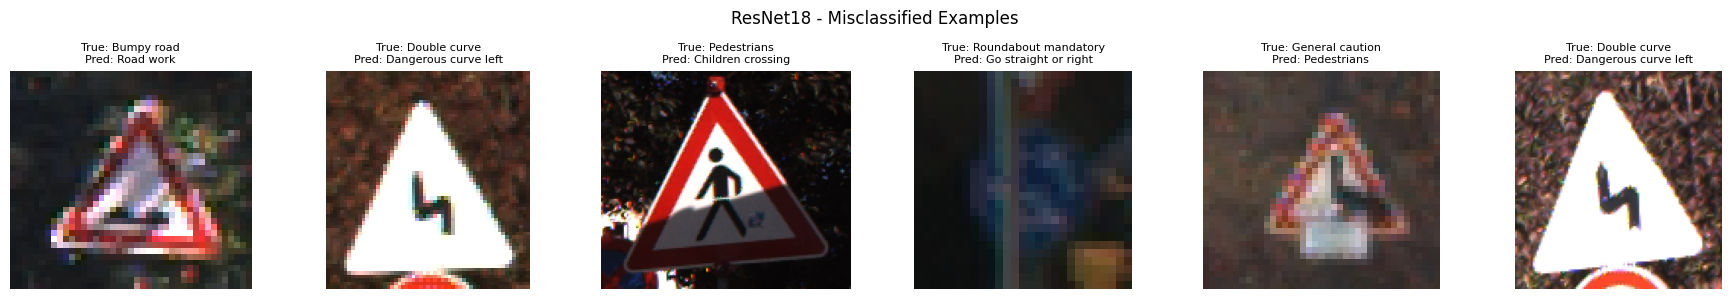

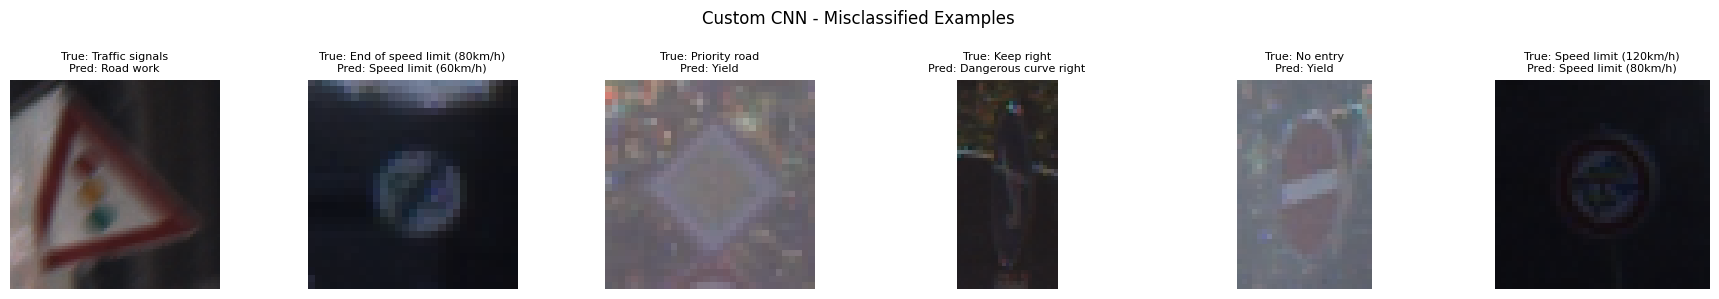

In [37]:

import matplotlib.pyplot as plt
np.random.seed(42)

def show_misclassified(preds, labels, df, root, model_name, n=6):
    preds = np.array(preds)
    labels = np.array(labels)
    wrong_idx = np.where(preds != labels)[0]
    chosen = np.random.choice(wrong_idx, size=n, replace=False)

    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    fig.suptitle(f'{model_name} - Misclassified Examples')

    for ax, idx in zip(axes, chosen):
        row = df.iloc[idx]
        img = Image.open(os.path.join(root, row['Path'])).convert('RGB')
        true_name = class_names[labels[idx]]
        pred_name = class_names[preds[idx]]

        ax.imshow(img)
        ax.set_title(f'True: {true_name}\nPred: {pred_name}', fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_misclassified(resnet_preds, resnet_labels, test_dataframe, data_root, 'ResNet18', n=6)
show_misclassified(custom_preds, custom_labels, test_dataframe, data_root, 'Custom CNN', n=6)

## Convergence graph

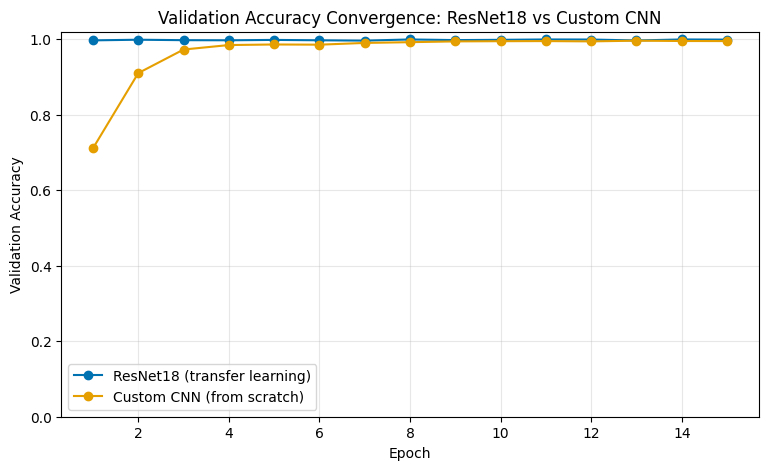

In [38]:
resnet_val_acc = [0.9971, 0.9988, 0.9976, 0.9973, 0.9983, 0.9973, 0.9964,
                   0.9995, 0.9978, 0.9985, 0.9995, 0.9993, 0.9968, 0.9995, 0.9991]
custom_val_acc = [0.7112, 0.9104, 0.9728, 0.9847, 0.9862, 0.9857, 0.9903,
                   0.9923, 0.9944, 0.9949, 0.9952, 0.9944, 0.9963, 0.9954, 0.9952]

epochs = range(1, 16)

plt.figure(figsize=(9, 5))
plt.plot(epochs, resnet_val_acc, marker='o', color='#0072B2', label='ResNet18 (transfer learning)')
plt.plot(epochs, custom_val_acc, marker='o', color='#E69F00', label='Custom CNN (from scratch)')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Convergence: ResNet18 vs Custom CNN')
plt.ylim(0, 1.02)
plt.legend()
plt.grid(alpha=0.3)
plt.show()